<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana7/Semana7_Dia3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIA 2: AUDITORIA VISUAL DE IoU E CAIXAS DELIMITADORAS


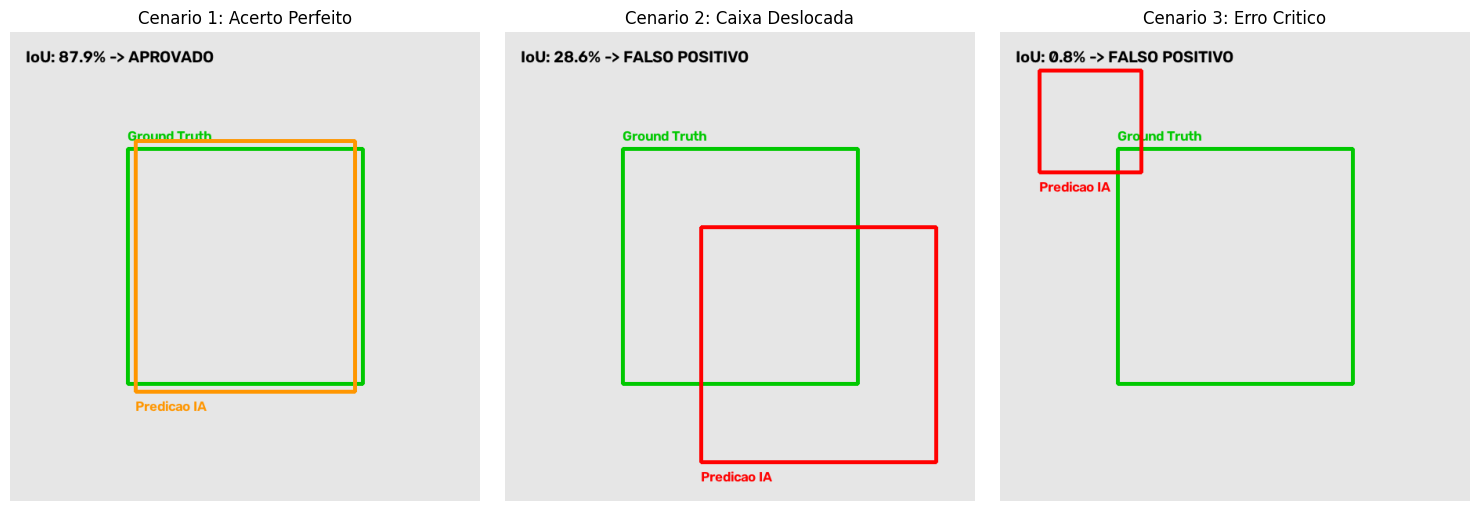


[EXPLICAÇÃO DIDÁTICA]:
- Verde: A marcação correta feita pelo engenheiro humano.
- Azul/Vermelho: O desenho gerado pela IA. Se o IoU cruzar os 50%, fica azul (TP).
- Se a caixa escorregar e o IoU cair, vira vermelho (FP), punindo a predição no boletim mAP.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("="*75)
print("DIA 2: AUDITORIA VISUAL DE IoU E CAIXAS DELIMITADORAS")
print("="*75)

# ==============================================================================
# 1. A MATEMÁTICA DO IoU (Intersection over Union)
# ==============================================================================
def calcular_iou_absoluto(boxA, boxB):
    """Calcula o IoU entre duas caixas no formato Pascal VOC [Xmin, Ymin, Xmax, Ymax]"""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    intersecao = max(0, xB - xA) * max(0, yB - yA)
    area_A = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_B = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    uniao = float(area_A + area_B - intersecao)

    return intersecao / uniao if uniao > 0 else 0.0

# ==============================================================================
# 2. SIMULAÇÃO VISUAL DE AUDITORIA NA ESTEIRA
# ==============================================================================
# Criamos um fundo de tela simulando a câmera da fábrica (600x600 pixels)
canvas_base = np.ones((600, 600, 3), dtype=np.uint8) * 230

# O Engenheiro anotou o local exato da peça real (Ground Truth) em Verde
gabarito_real = [150, 150, 450, 450]

# Vamos testar 3 comportamentos diferentes da IA para desenhar na tela:
# Predição 1: Acerto perfeito (Alta sobreposição)
# Predição 2: Caixa deslocada (Alarme falso / Baixo IoU)
# Predição 3: Caixa muito pequena ou errada
predicoes_teste = [
    [160, 140, 440, 460], # IA 1: Ótimo encaixe
    [250, 250, 550, 550], # IA 2: Caixa escorregou pela metade
    [50, 50, 180, 180]    # IA 3: Erro total de localização
]

titulos_cenarios = ["Cenario 1: Acerto Perfeito", "Cenario 2: Caixa Deslocada", "Cenario 3: Erro Critico"]
limiar_iou = 0.50

plt.figure(figsize=(15, 5))

for i, predicao in enumerate(predicoes_teste):
    # Copia a tela base para desenhar o cenário atual
    img_cenario = canvas_base.copy()

    # Calcula a métrica IoU
    iou_atingido = calcular_iou_absoluto(gabarito_real, predicao)
    status_aprovacao = iou_atingido >= limiar_iou

    # 1. Desenha a caixa REAL do Humano (Verde)
    cv2.rectangle(img_cenario, (gabarito_real[0], gabarito_real[1]),
                  (gabarito_real[2], gabarito_real[3]), (0, 200, 0), 3)
    cv2.putText(img_cenario, "Ground Truth", (gabarito_real[0], gabarito_real[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

    # 2. Desenha a caixa da IA (Azul se aprovada, Vermelha se reprovada pelo IoU)
    cor_ia = (0, 150, 255) if status_aprovacao else (0, 0, 255) # Azul ou Vermelho (BGR)
    cv2.rectangle(img_cenario, (predicao[0], predicao[1]),
                  (predicao[2], predicao[3]), cor_ia, 3)
    cv2.putText(img_cenario, "Predicao IA", (predicao[0], predicao[3] + 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor_ia, 2)

    # 3. Escreve o resultado do IoU direto no desenho para os alunos verem
    texto_status = f"IoU: {iou_atingido*100:.1f}% -> {'APROVADO' if status_aprovacao else 'FALSO POSITIVO'}"
    cv2.putText(img_cenario, texto_status, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # Plotando no Matplotlib
    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(img_cenario, cv2.COLOR_BGR2RGB))
    plt.title(titulos_cenarios[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n[EXPLICAÇÃO DIDÁTICA]:")
print("- Verde: A marcação correta feita pelo engenheiro humano.")
print("- Azul/Vermelho: O desenho gerado pela IA. Se o IoU cruzar os 50%, fica azul (TP).")
print("- Se a caixa escorregar e o IoU cair, vira vermelho (FP), punindo a predição no boletim mAP.")